In [1]:
import warnings
import sys
import os
sys.path.append(os.path.abspath("path"))
warnings.filterwarnings('ignore')
from pm4py.analysis import check_is_workflow_net, check_soundness
from fedap_utils import *
from pm4py.algo.discovery.alpha.variants.plus import apply_aggr

### Filtering

In [2]:
pa_el, pa_df = load_convert_el(el_path=r"./data/proact.csv", case_id='ID', activity_key='Event', timestamp_key='Date')
print(pa_df['Event'].unique())
list_events = ['Onset', 'Start_trial', 'M_0000', 'Censored','M_0100', 'Dead', 'M_1000',
 'M_1010', 'M_1001', 'M_0001', 'M_0110', 'M_1100', 'M_0010',
 'M_0101', 'M_0011']
pa_df_filt = pa_df[pa_df['Event'].isin(list_events)]

threshold=100
event_count = pa_df_filt['Event'].value_counts()
pa_df_filt = pa_df_filt[pa_df_filt['Event'].isin(event_count[event_count >= threshold].index)]
pa_df_filt = pa_df_filt[pa_df_filt['ID'] != 544698]
pa_df_filt.to_csv('./data/pa_df_filtered.csv', index=False)

['Onset' 'Start_trial' 'M_0000' 'Censored' 'M_0100' 'Dead' 'M_1000'
 'M_1010' 'M_1110' 'M_1001' 'M_1111' 'M_0110' 'M_0001' 'M_1011' 'M_1100'
 'M_0101' 'M_0010' 'M_1101' 'M_0111' 'M_0011']


In [3]:
import numpy as np

id_list = pa_df_filt['ID'].unique()

random_seed = 42 # For reproducibility
np.random.seed(random_seed)
np.random.shuffle(id_list)

id_groups = np.array_split(id_list, 4)

df_path_list = []
for i, id_split in enumerate(id_groups):
	splitted = pa_df_filt[pa_df_filt['ID'].isin(id_split)]
	path = f"./data/proact_split{i}.csv"
	df_path_list.append(path)
	splitted.to_csv(path_or_buf=path, index=False)

event_log_tot, df_tot = load_convert_el(el_path=r"./data/pa_df_filtered.csv", case_id='ID', activity_key='Event', timestamp_key='Date')
el_splits = []
for path_split in df_path_list:
	el_split, _ = load_convert_el(el_path=path_split, case_id='ID', activity_key='Event', timestamp_key='Date')
	el_splits.append(el_split)

# RWD Testing

## Processing

### AA+ on the entire event log


Entire Event Log (Alpha+):
1-length-loop free net soundness: False


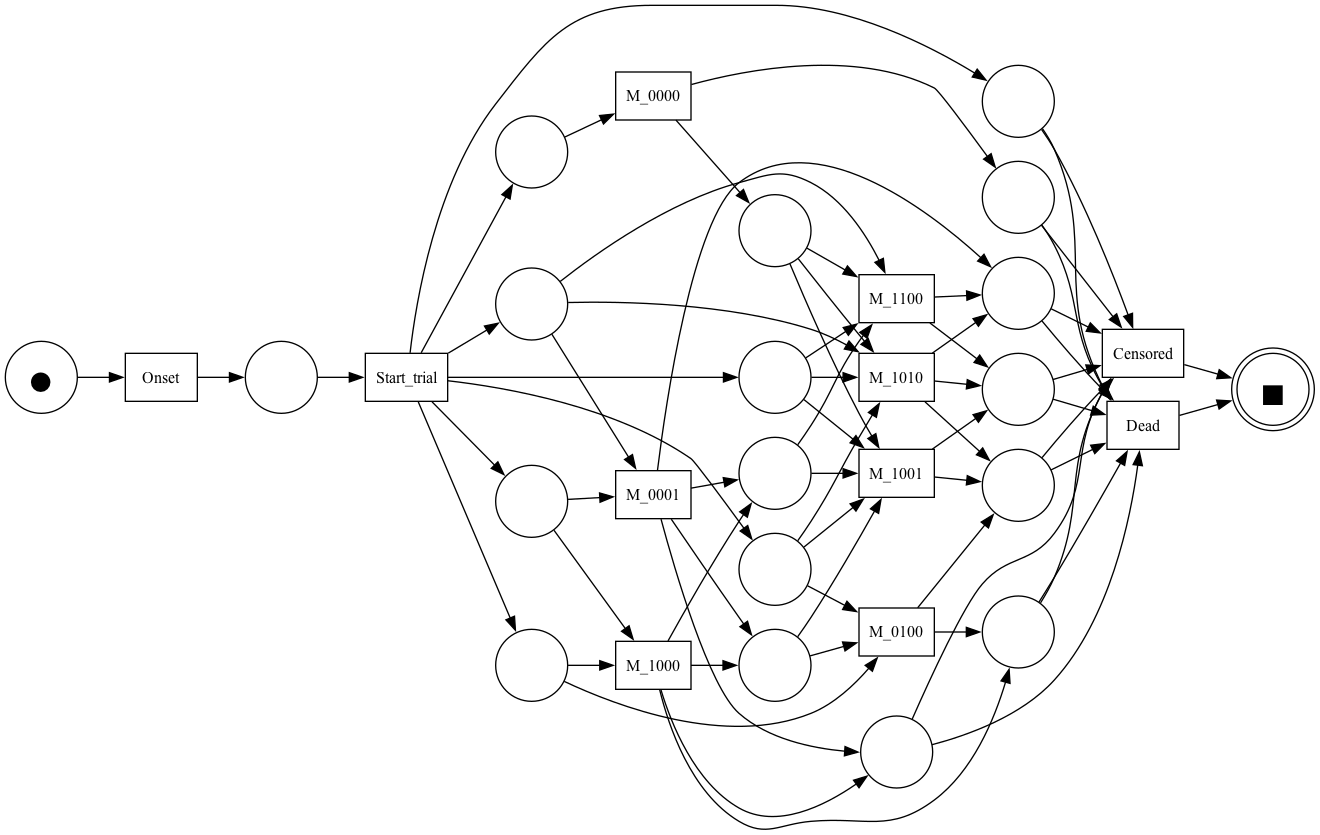

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead'}
	M_1000
		{'Censored', 'M_1001', 'Dead', 'M_1100'}
	Censored
		{'artificial_end'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_0100
		{'Censored', 'Dead'}
	M_0001
		{'Censored', 'M_1001', 'M_0100', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
parallel
	M_0000
		{'M_1000', 'M_0100', 'M_0001'}
	M_1000
		{'M_1010', 'M_0000'}
	M_1100
		{'M_0100'}
	M_0100
		{'M_1100', 'M_0000'}
	M_0001
		{'M_0000'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored

In [4]:
print('\nEntire Event Log (Alpha+):')
net_tot, initial_marking_tot, final_marking_tot, footprint_matrix_tot, loop_one_list_tot, oneL_inputs_tot, oneL_outputs_tot = apply_monocentric(event_log_tot)

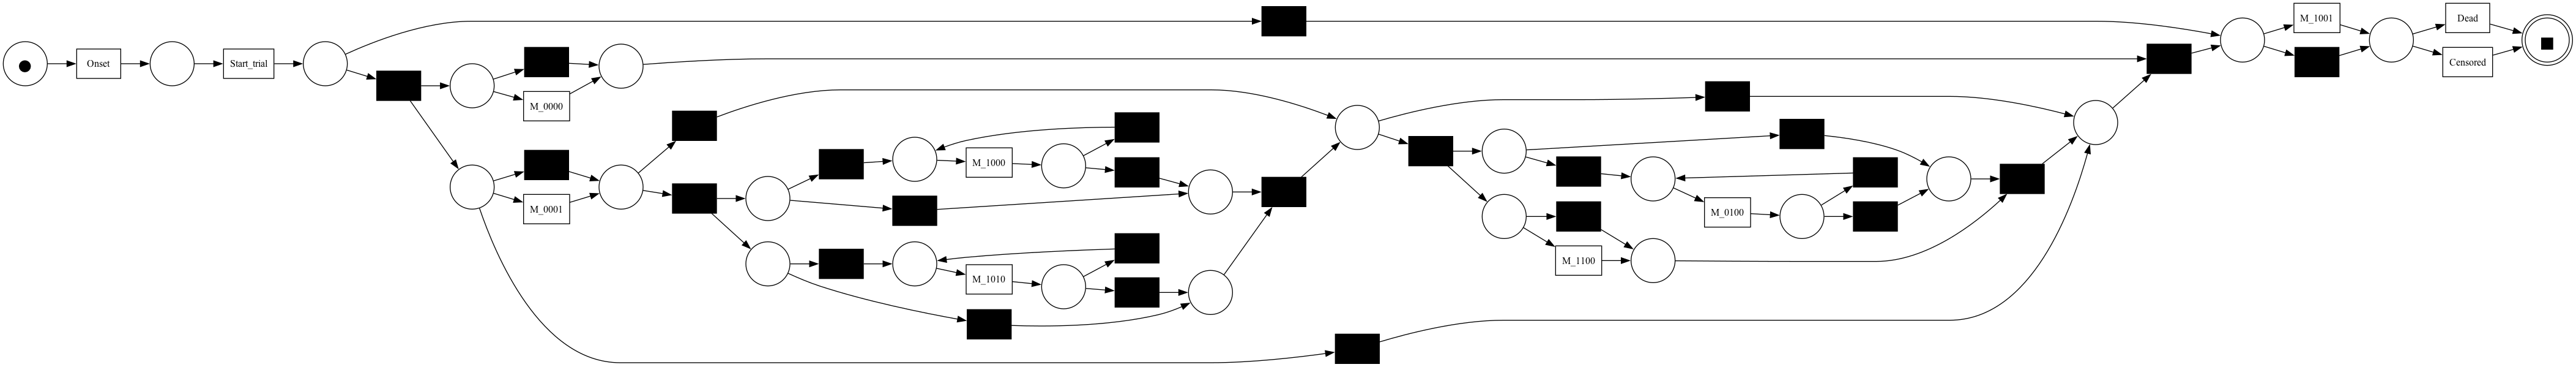

In [5]:
net_ind, initial_marking_ind, final_marking_ind = pm4py.discover_petri_net_inductive(event_log_tot)
pm4py.view_petri_net(net_ind, initial_marking_ind, final_marking_ind)


### Monocentric processing
FMs are computed independently over different event log splits

1-length-loop free net soundness: False


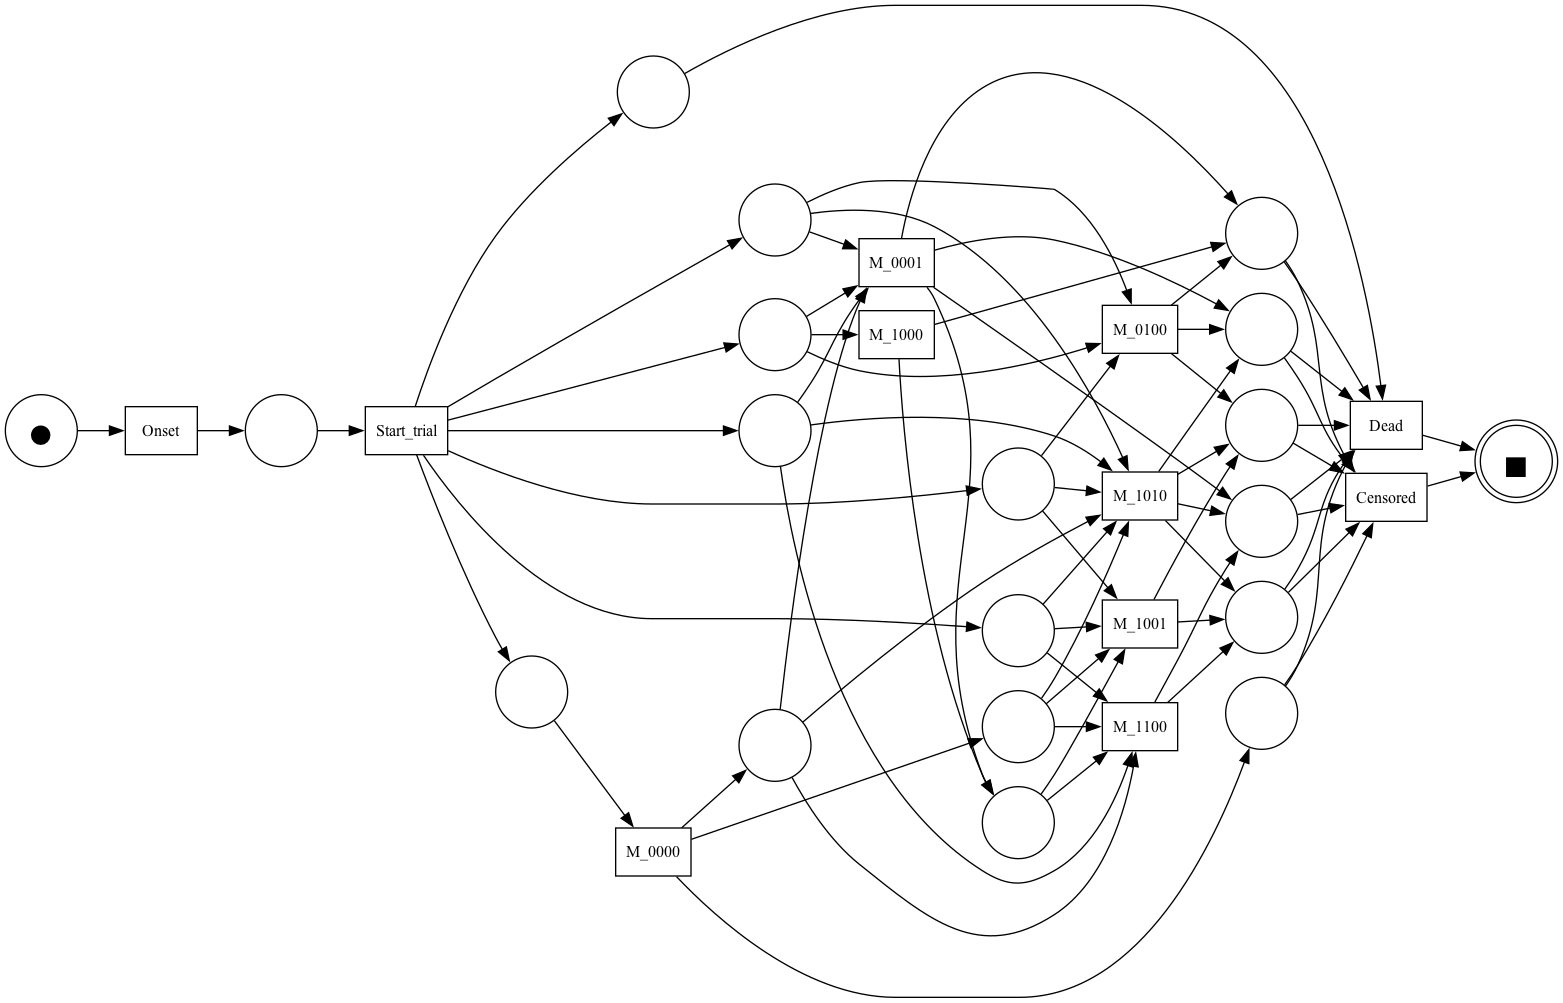

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'Dead'}
	M_1000
		{'Censored', 'M_1001', 'Dead', 'M_1100'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'Dead'}
	Censored
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	M_0001
		{'Censored', 'M_1001', 'Dead'}
parallel
	M_0000
		{'M_1000', 'M_0100'}
	M_1000
		{'M_1010', 'M_0000'}
	M_0100
		{'M_1100', 'M_0000'}
	M_1100
		{'M_0100'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead', 'M_0000'}
	M_1001
		{'Censored', '

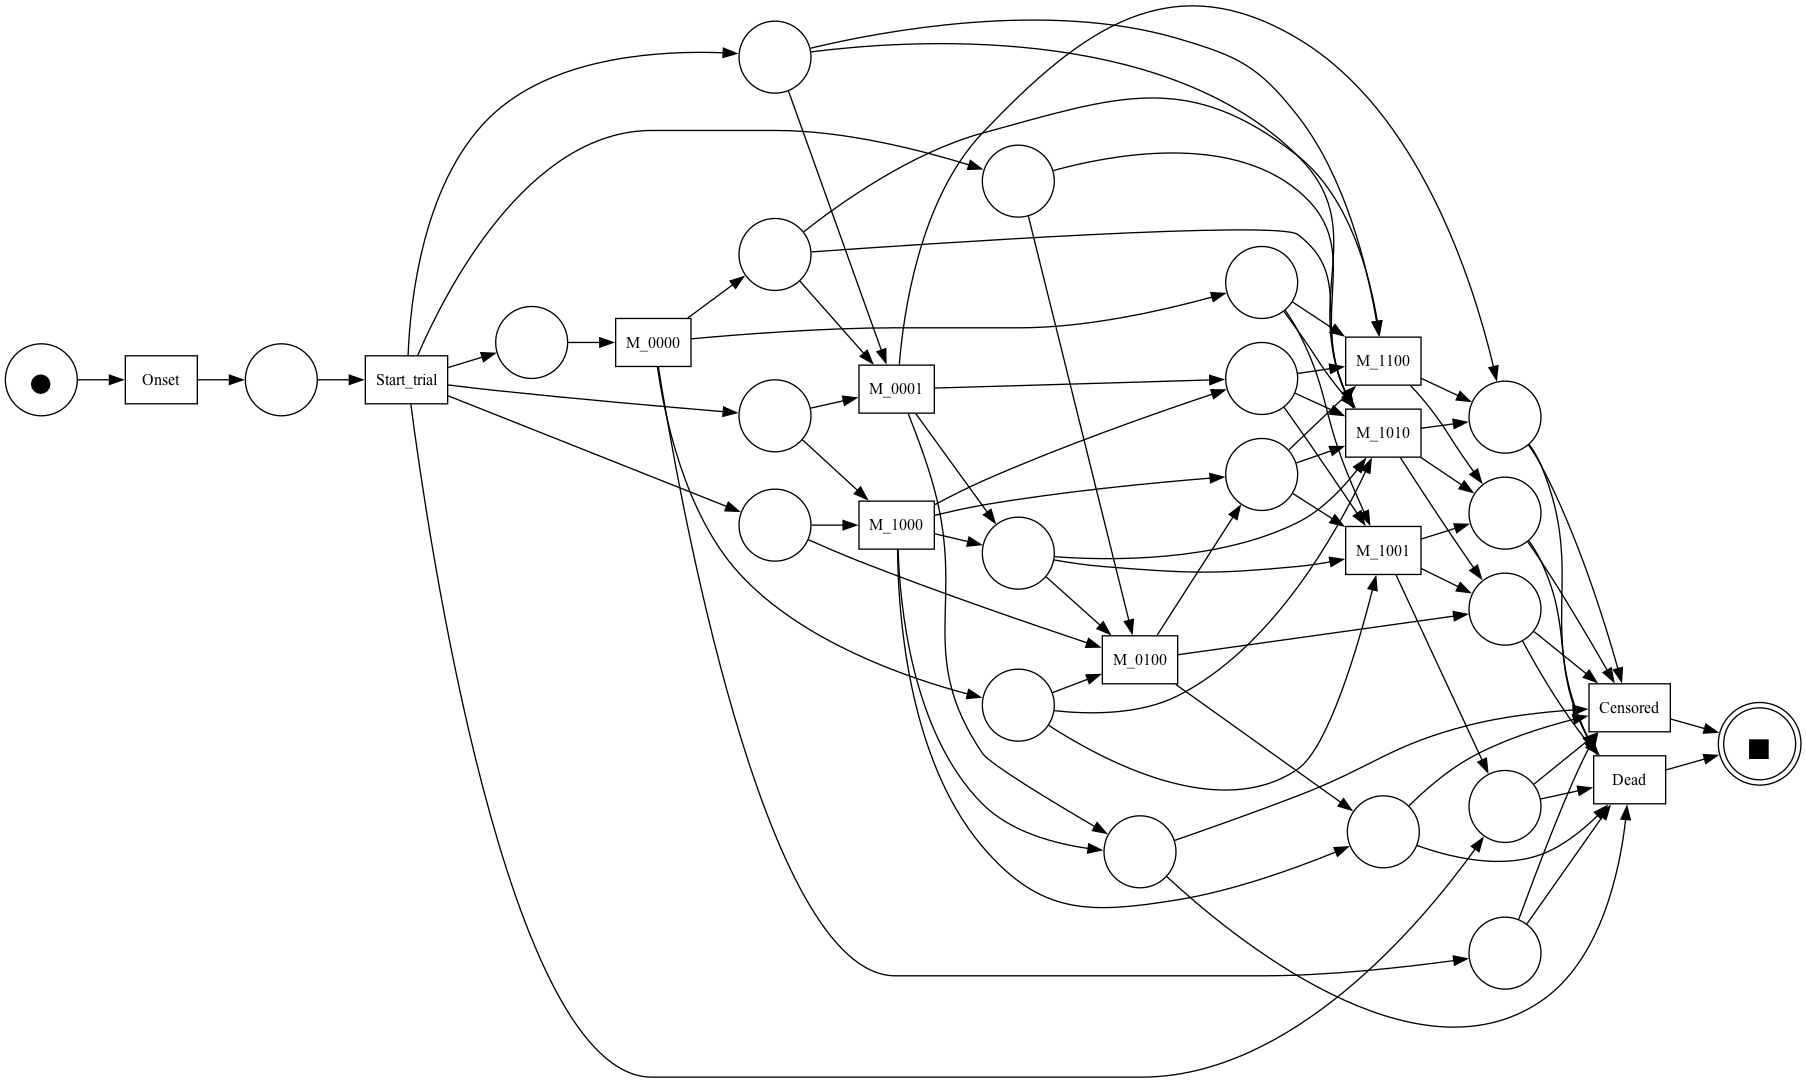

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Censored', 'Dead'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead'}
	M_1001
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_0001
		{'Censored', 'M_1001', 'M_0100', 'Dead'}
parallel
	M_1000
		{'M_0000'}
	M_0000
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000', 'M_0000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead', 'M_0000'}
	M_1100
		{'Censored', 'Dead'}
	Censored
		{'artificial_end'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000'}
	M_1001
		{

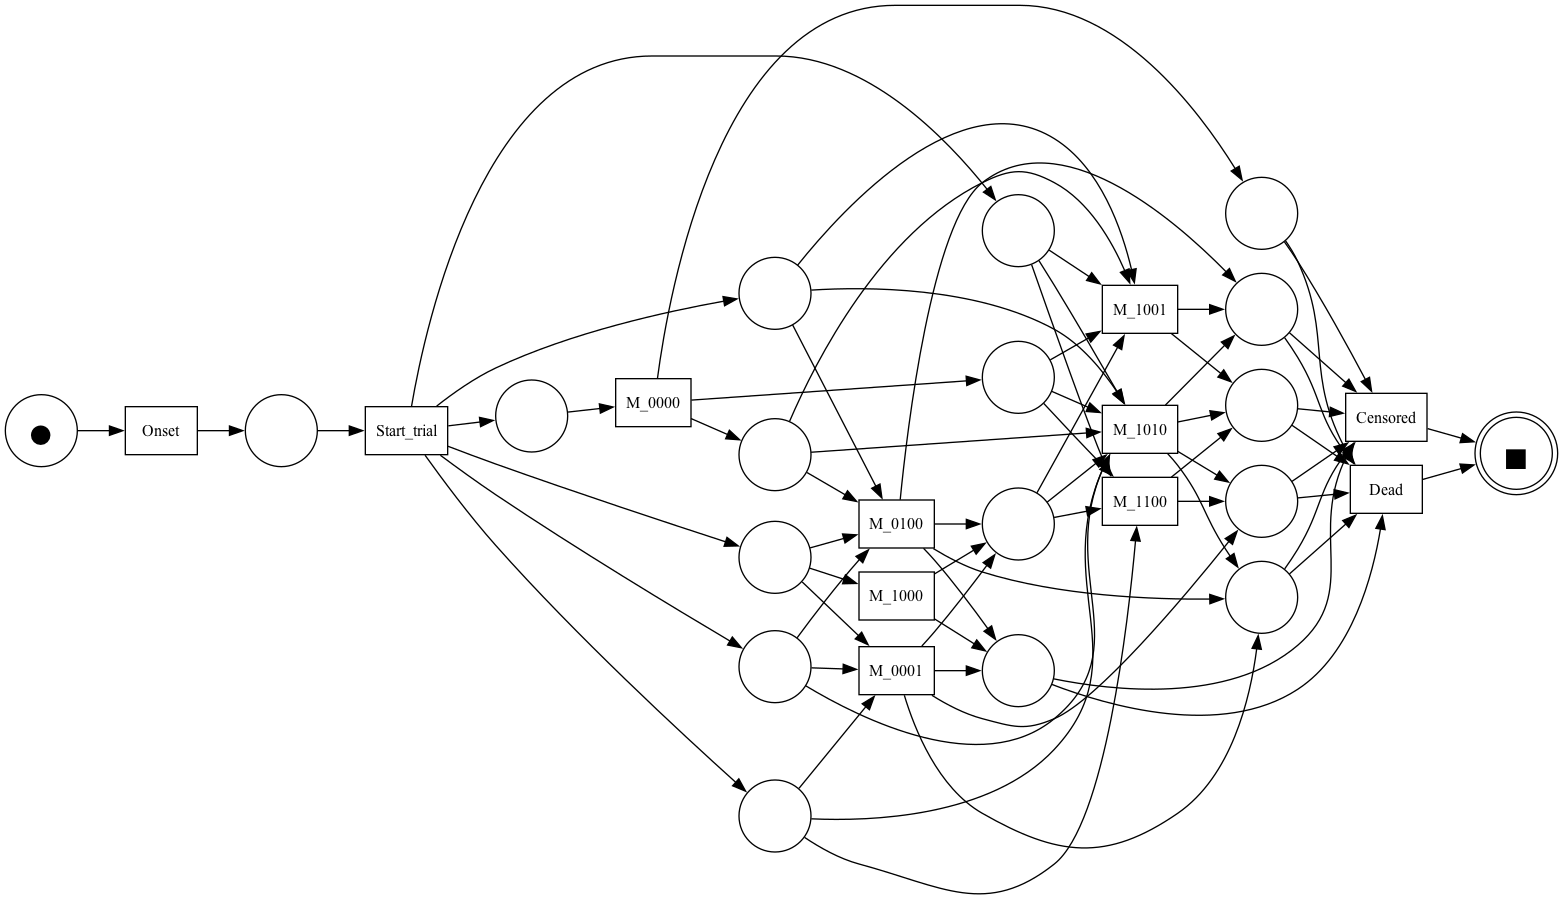

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'M_0100', 'Dead'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead'}
	Censored
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_1001
		{'Censored', 'Dead'}
	M_0001
		{'Censored', 'M_1001', 'Dead'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
parallel
	M_0000
		{'M_1000', 'M_0001'}
	M_1000
		{'M_0000'}
	M_0001
		{'M_0000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead', 'M_0000'}
	Censored
		{'artificial_end'}
	M_1100
		{'Censored', 'Dead'}
	M_1010
		{'Censored

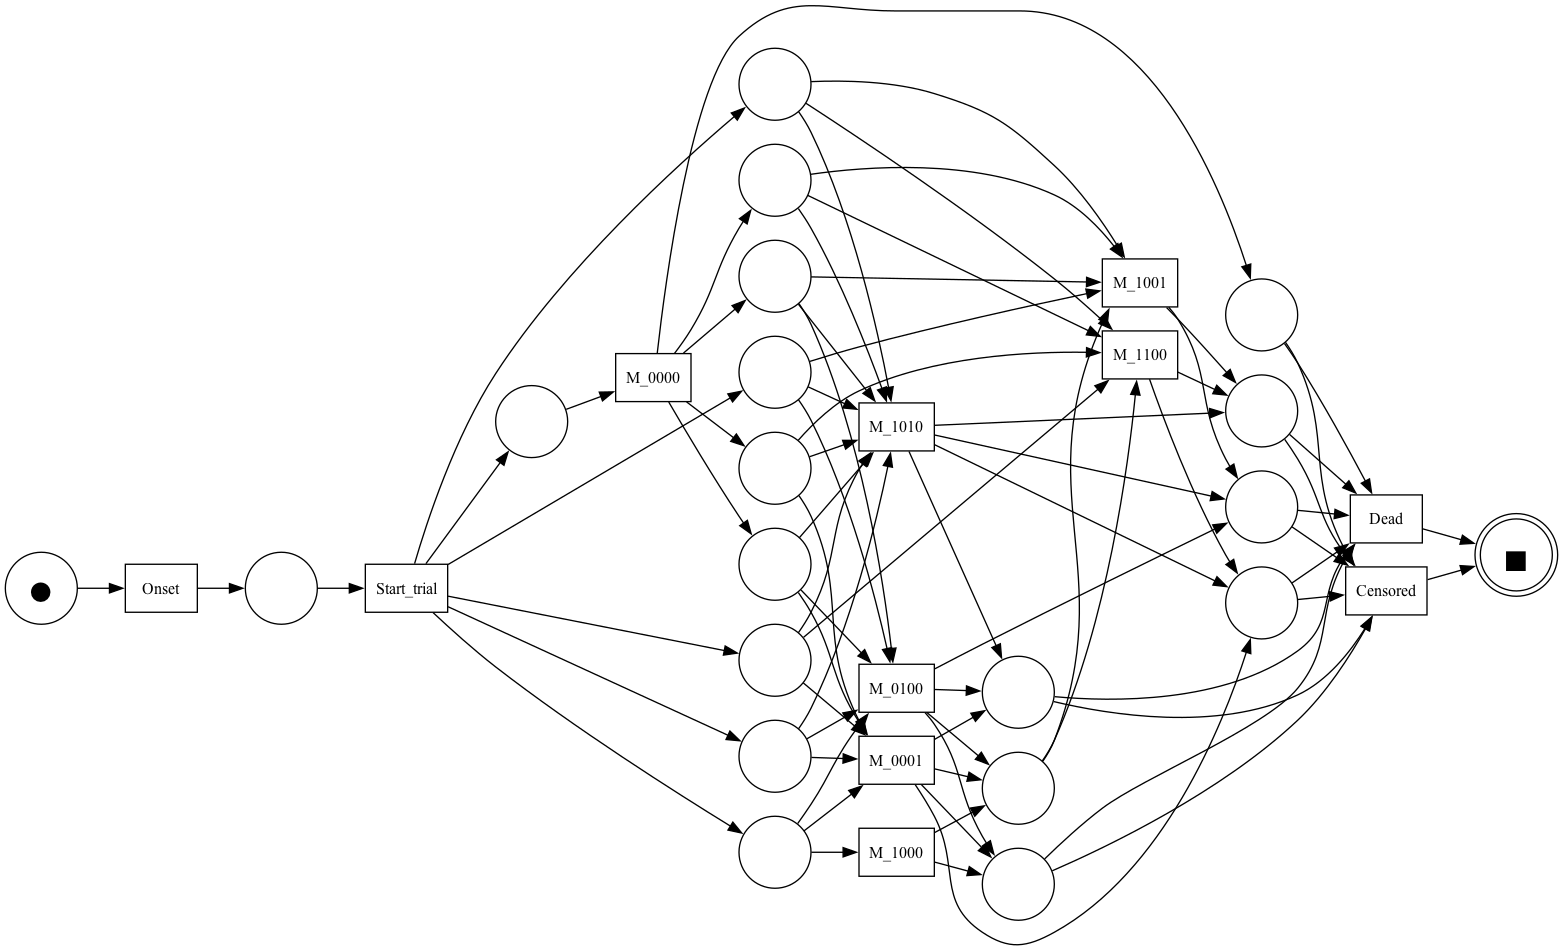

Relations:
 causal
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead'}
	M_1000
		{'Censored', 'M_1001', 'Dead', 'M_1100'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0001
		{'Censored', 'M_1001', 'Dead'}
	Censored
		{'artificial_end'}
	M_0100
		{'Censored', 'M_1100', 'Dead'}
	M_1100
		{'Censored', 'Dead'}
	M_1010
		{'Censored', 'Dead'}
parallel
	M_0000
		{'M_1000'}
	M_1000
		{'M_1010', 'M_0000'}
	M_1010
		{'M_1000'}
follows
	artificial_start
		{'Onset'}
	Onset
		{'Start_trial'}
	Start_trial
		{'M_1010', 'M_1001', 'M_0001', 'M_1100', 'M_0100', 'M_1000', 'M_0000'}
	M_0000
		{'M_1010', 'M_1001', 'M_0001', 'Censored', 'M_1100', 'M_0100', 'Dead', 'M_1000'}
	M_1000
		{'M_1010', 'M_1001', 'Censored', 'M_1100', 'Dead', 'M_0000'}
	M_1001
		{'Censored', 'Dead'}
	Dead
		{'artificial_end'}
	M_0001
		{'Censored', '

In [6]:
FTs, oneL_inputs_dic, oneL_outputs_dic, loop_one_tot_list = simulate_nodes_computation(el_splits=el_splits)

In [7]:
sum_FT, events = pm4py.algo.discovery.alpha.variants.plus.aggregate_fms(fts=FTs)

print('Aggregated Footprint Matrix:\n')
display(sum_FT)

print('Total Footprint Matrix:\n')
display(footprint_matrix_tot)

print(f'Test equality between Total Footprint and Aggregated Footprint Matrix: {footprint_matrix_tot.equals(sum_FT)}\n')

assert footprint_matrix_tot.equals(sum_FT)

Footprint Matrixes to aggregate:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,->,||,||,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,T,#,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,->,->,||,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,->,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,<-,#,#,#,#,->,#,<-
M_1000,#,#,->,->,T,#,#,#,->,->,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,#
M_1010,#,#,->,->,<-,#,#,<-,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
M_0000,#,#,->,->,#,||,->,||,->,->,->,#,<-
M_0001,#,#,->,->,||,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,#,#,#,#,#,->,#,<-
M_1000,#,#,->,->,T,#,#,#,->,->,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,<-,#,#,#,#,<-


,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,#
M_0000,#,#,->,->,#,->,->,||,->,->,->,#,<-
M_0001,#,#,->,->,<-,#,#,#,->,#,#,#,<-
M_0100,#,#,->,->,<-,#,#,#,#,#,->,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,||,#,#,#,#,<-




Aggregated Footprint Matrix:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,||,||,||,->,->,->,#,<-
M_0001,#,#,->,->,||,#,->,#,->,#,#,#,<-
M_0100,#,#,->,->,T,<-,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


Total Footprint Matrix:



,artificial_start,artificial_end,Censored,Dead,M_0000,M_0001,M_0100,M_1000,M_1001,M_1010,M_1100,Onset,Start_trial
artificial_start,#,#,#,#,#,#,#,#,#,#,#,->,#
artificial_end,#,#,<-,<-,#,#,#,#,#,#,#,#,#
Censored,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
Dead,#,->,#,#,<-,<-,<-,<-,<-,<-,<-,#,<-
M_0000,#,#,->,->,#,||,||,||,->,->,->,#,<-
M_0001,#,#,->,->,||,#,->,#,->,#,#,#,<-
M_0100,#,#,->,->,T,<-,#,#,#,#,||,#,<-
M_1000,#,#,->,->,T,#,#,#,->,||,->,#,<-
M_1001,#,#,->,->,<-,<-,#,<-,#,#,#,#,<-
M_1010,#,#,->,->,<-,#,#,T,#,#,#,#,<-


Test equality between Total Footprint and Aggregated Footprint Matrix: True



1-length-loop free net soundness: False


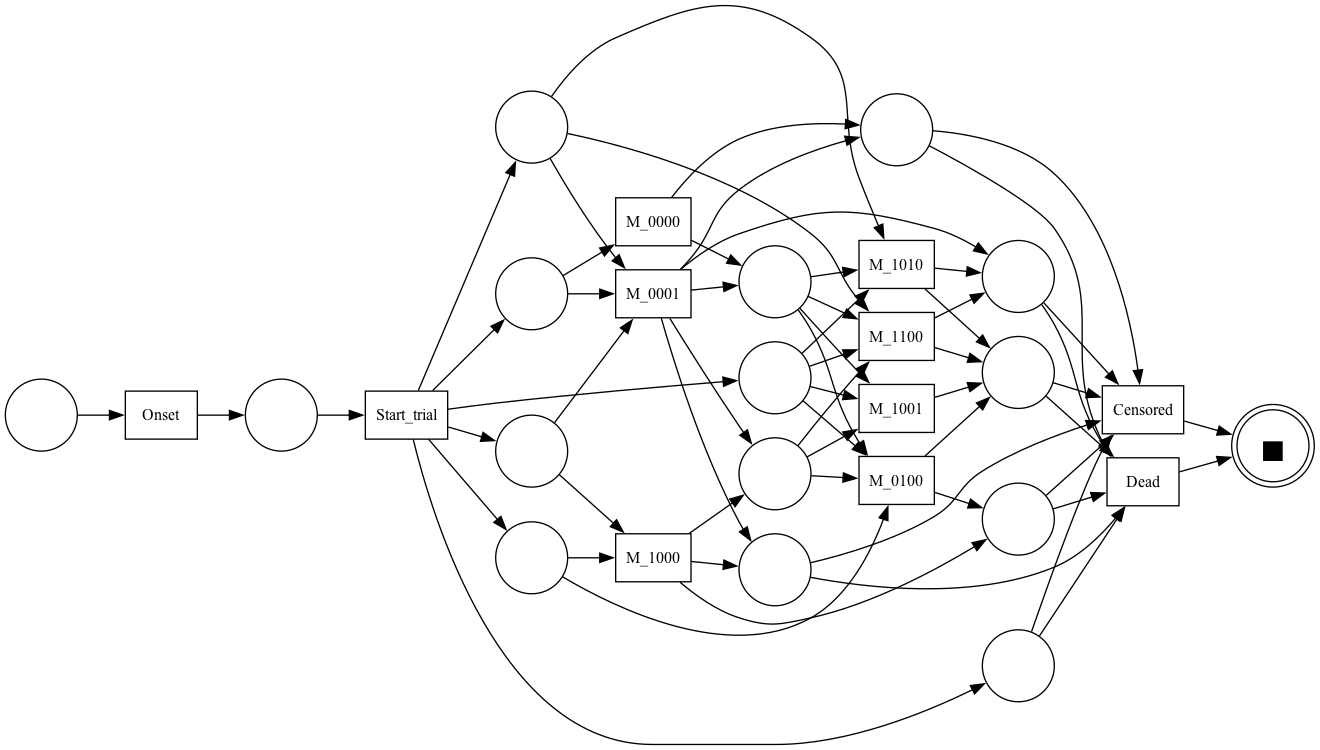

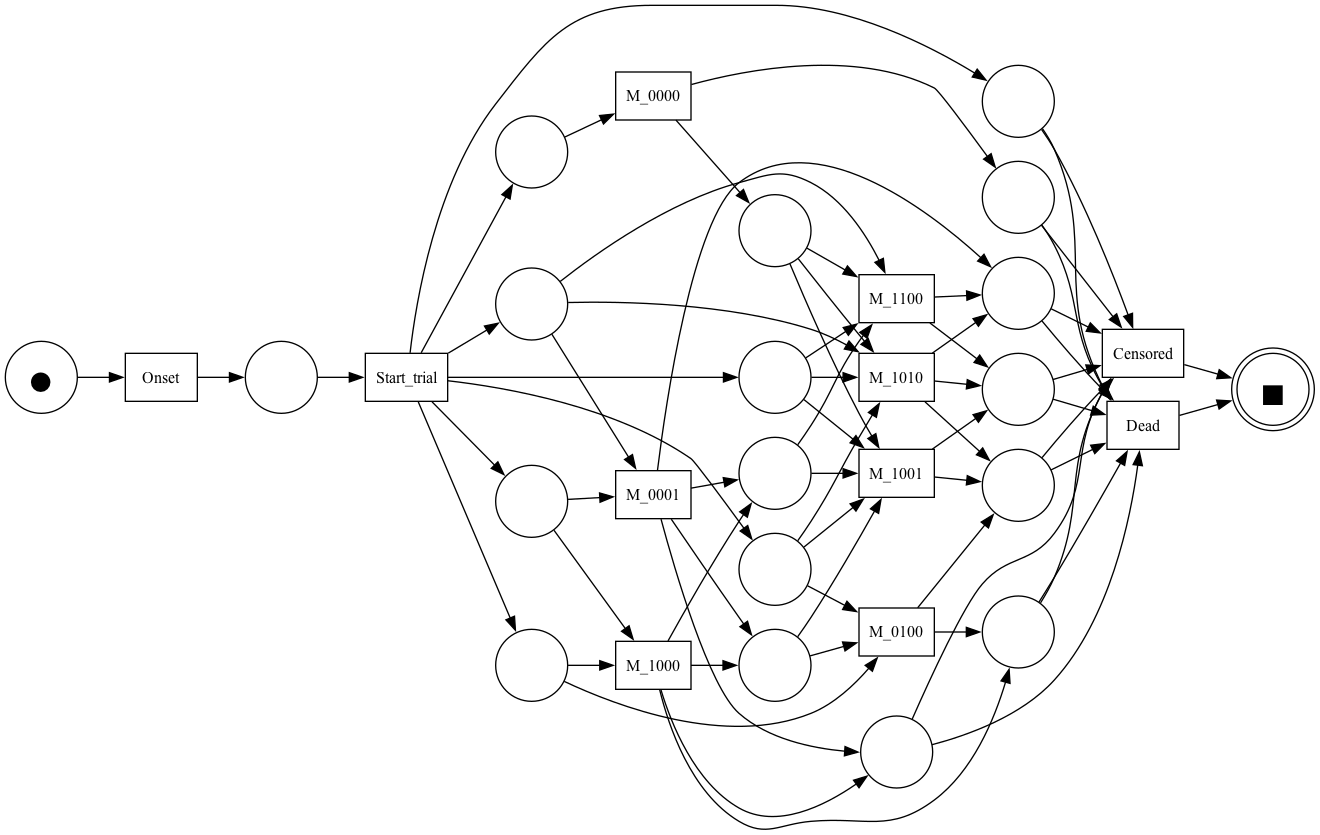

In [8]:
net_final, initial_marking_final, final_marking_final = apply_aggr(fm=sum_FT,
                                                                   events=events,
                                                                   oneL_inputs=oneL_inputs_dic,
                                                                   oneL_outputs=oneL_outputs_dic,
                                                                   loop_one_list=loop_one_list_tot
                                                                   )

pm4py.view_petri_net(net_final, initial_marking_final, final_marking_final)
pm4py.view_petri_net(net_tot, initial_marking_tot, final_marking_tot)

# In Vitro Testing

In [9]:
event_log_tot_vitro, _ = load_convert_el(el_path=r"./data/EL.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')

el_splits_vitro = []
event_log_A, _ = load_convert_el(el_path=r"./data/EL_A.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')
event_log_B, _ = load_convert_el(el_path=r"./data/EL_B.csv", case_id='Case_ID', activity_key='Activity', timestamp_key='Timestamp')
el_splits_vitro.append(event_log_A)
el_splits_vitro.append(event_log_B)


Entire Event Log (Alpha+):
1-length-loop free net soundness: True


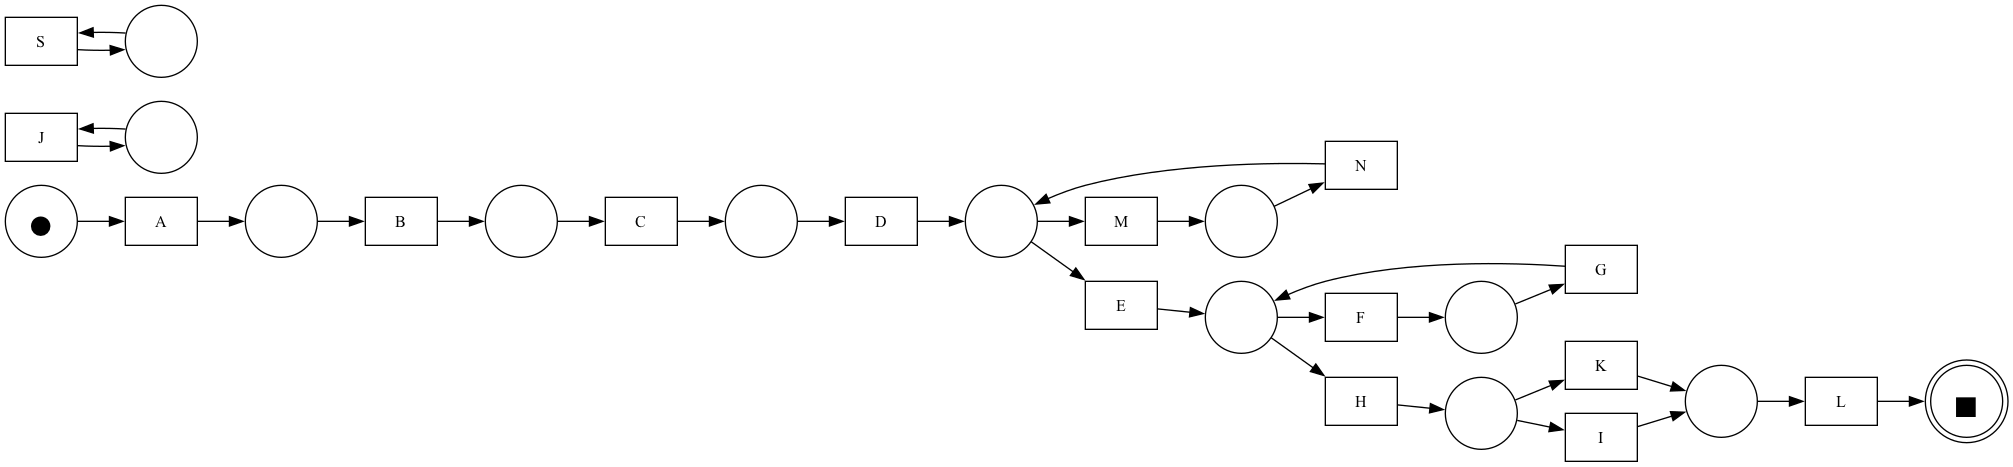

Relations:
 causal
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'F', 'H'}
	H
		{'K', 'I'}
	I
		{'L'}
	L
		{'artificial_end'}
	M
		{'N'}
	N
		{'E', 'M'}
	K
		{'L'}
parallel
follows
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'F', 'H'}
	H
		{'K', 'I'}
	I
		{'L'}
	L
		{'artificial_end'}
	M
		{'N'}
	N
		{'E', 'M'}
	K
		{'L'}
square
	F
		{'G'}
	G
		{'F'}
	M
		{'N'}
	N
		{'M'}
triangle
	F
		{'G'}
	G
		{'F'}
	M
		{'N'}
	N
		{'M'}

Length One Loop Inputs:
 J
	{'B'}
S
	{'C'}

Length One Loop Outputs:
 J
	{'C'}
S
	{'D'}



In [10]:
print('\nEntire Event Log (Alpha+):')
net_tot_vitro, initial_marking_tot_vitro, final_marking_tot_vitro, footprint_matrix_tot_vitro, loop_one_list_tot_vitro, oneL_inputs_tot_vitro, oneL_outputs_tot_vitro= apply_monocentric(event_log_tot_vitro)

1-length-loop free net soundness: True


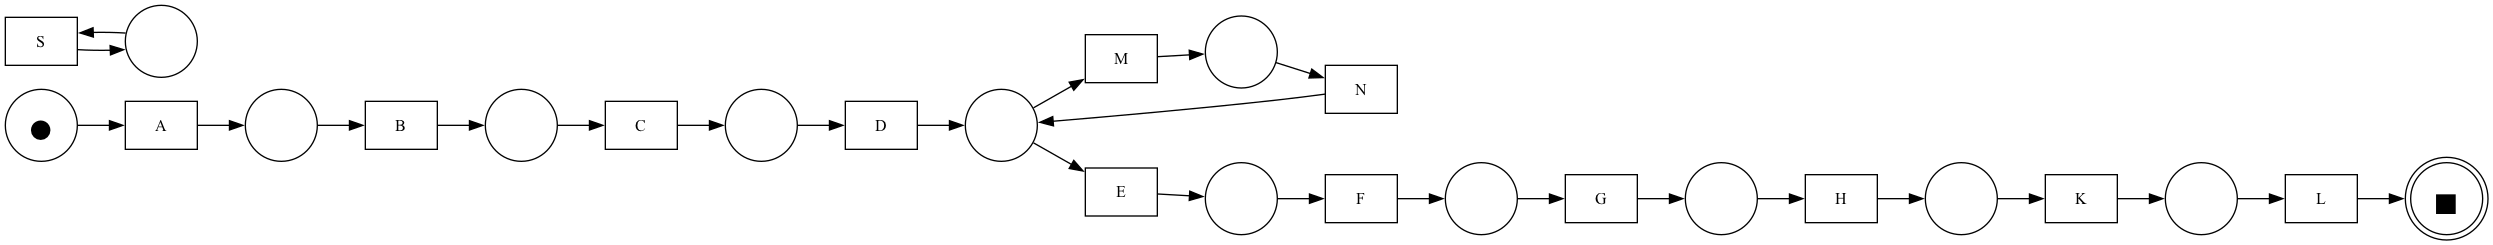

Relations:
 causal
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'M'}
	M
		{'N'}
	N
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'H'}
	H
		{'K'}
	K
		{'L'}
	L
		{'artificial_end'}
parallel
follows
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'M'}
	M
		{'N'}
	N
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'H'}
	H
		{'K'}
	K
		{'L'}
	L
		{'artificial_end'}
square
	M
		{'N'}
	N
		{'M'}
triangle
	M
		{'N'}
	N
		{'M'}

Length One Loop Inputs:
 S
	{'C'}

Length One Loop Outputs:
 S
	{'D'}

1-length-loop free net soundness: True


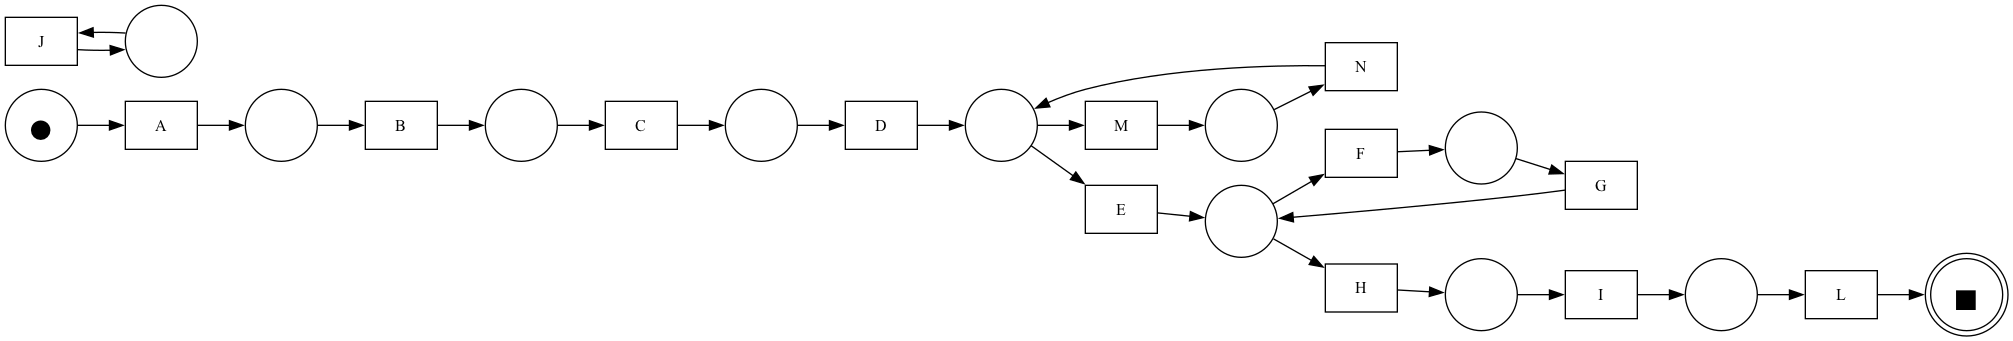

Relations:
 causal
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'F', 'H'}
	H
		{'I'}
	I
		{'L'}
	L
		{'artificial_end'}
	M
		{'N'}
	N
		{'E', 'M'}
parallel
follows
	artificial_start
		{'A'}
	A
		{'B'}
	B
		{'C'}
	C
		{'D'}
	D
		{'E', 'M'}
	E
		{'F'}
	F
		{'G'}
	G
		{'F', 'H'}
	H
		{'I'}
	I
		{'L'}
	L
		{'artificial_end'}
	M
		{'N'}
	N
		{'E', 'M'}
square
	F
		{'G'}
	G
		{'F'}
	M
		{'N'}
	N
		{'M'}
triangle
	F
		{'G'}
	G
		{'F'}
	M
		{'N'}
	N
		{'M'}

Length One Loop Inputs:
 J
	{'B'}

Length One Loop Outputs:
 J
	{'C'}

Footprint Matrixes to aggregate:



,artificial_start,artificial_end,A,B,C,D,E,F,G,H,I,K,L,M,N
artificial_start,#,#,->,#,#,#,#,#,#,#,#,#,#,#,#
artificial_end,#,#,#,#,#,#,#,#,#,#,#,#,<-,#,#
A,<-,#,#,->,#,#,#,#,#,#,#,#,#,#,#
B,#,#,<-,#,->,#,#,#,#,#,#,#,#,#,#
C,#,#,#,<-,#,->,#,#,#,#,#,#,#,#,#
D,#,#,#,#,<-,#,#,#,#,#,#,#,#,->,#
E,#,#,#,#,#,#,#,->,#,#,#,#,#,#,<-
F,#,#,#,#,#,#,<-,#,->,#,#,#,#,#,#
G,#,#,#,#,#,#,#,<-,#,->,#,#,#,#,#
H,#,#,#,#,#,#,#,#,<-,#,#,->,#,#,#


,artificial_start,artificial_end,A,B,C,D,E,F,G,H,I,K,L,M,N
artificial_start,#,#,->,#,#,#,#,#,#,#,#,#,#,#,#
artificial_end,#,#,#,#,#,#,#,#,#,#,#,#,<-,#,#
A,<-,#,#,->,#,#,#,#,#,#,#,#,#,#,#
B,#,#,<-,#,->,#,#,#,#,#,#,#,#,#,#
C,#,#,#,<-,#,->,#,#,#,#,#,#,#,#,#
D,#,#,#,#,<-,#,->,#,#,#,#,#,#,->,#
E,#,#,#,#,#,<-,#,->,#,#,#,#,#,#,<-
F,#,#,#,#,#,#,<-,#,S,#,#,#,#,#,#
G,#,#,#,#,#,#,#,S,#,->,#,#,#,#,#
H,#,#,#,#,#,#,#,#,<-,#,->,#,#,#,#




1-length-loop free net soundness: True


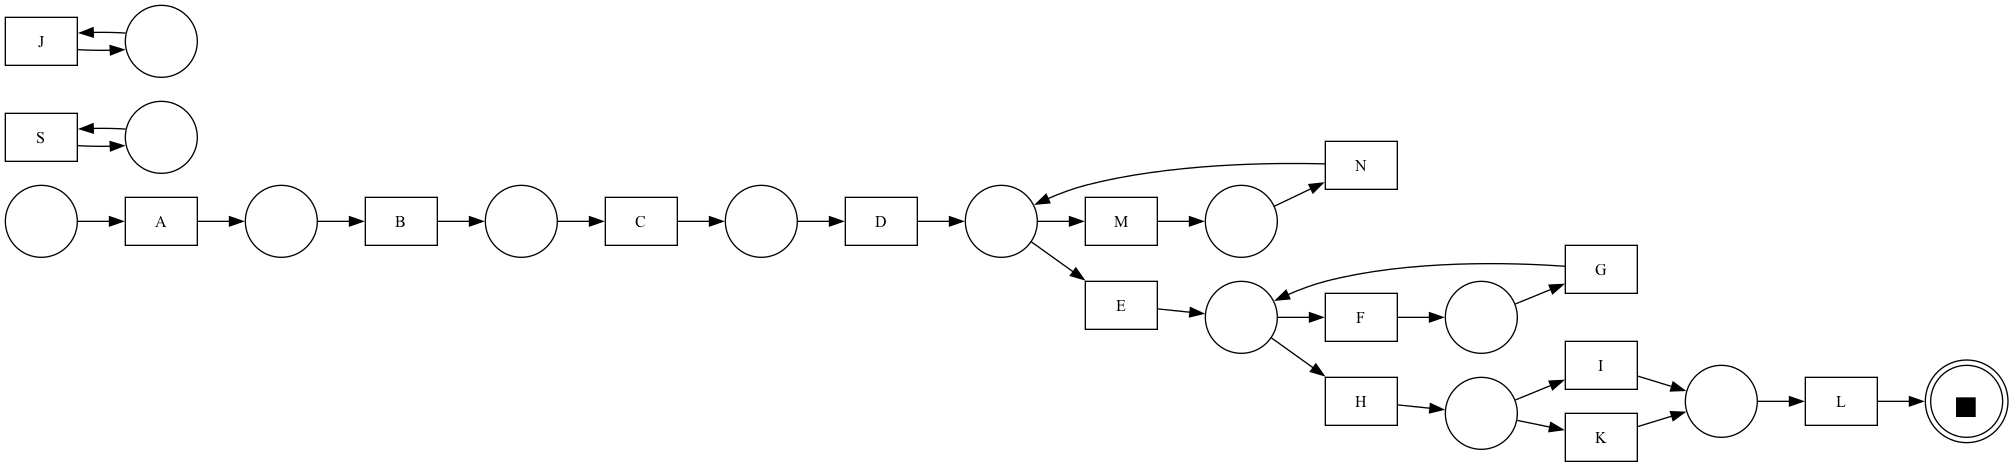

In [11]:
FTs_vitro, oneL_inputs_dic_vitro, oneL_outputs_dic_vitro, loop_one_list_vitro = simulate_nodes_computation(el_splits=el_splits_vitro)
sum_FT_vitro, events_vitro = pm4py.algo.discovery.alpha.variants.plus.aggregate_fms(fts=FTs_vitro)
net_vitro, initial_marking_vitro, final_marking_vitro = apply_aggr(fm=sum_FT_vitro,
                                                                   events=events_vitro,
                                                                   oneL_inputs=oneL_inputs_dic_vitro,
                                                                   oneL_outputs=oneL_outputs_dic_vitro,
                                                                   loop_one_list=loop_one_list_vitro
                                                                   )
assert sum_FT_vitro.equals(footprint_matrix_tot_vitro)
pm4py.view_petri_net(net_vitro, initial_marking_vitro, final_marking_vitro)